# LAVA 2026 Run Analysis

Analyze one `runs/<JOB_ID>/` folder produced by the current pipeline. The notebook supports both `test` runs, where there is no ground truth, and `train` runs, where score columns are available.

In [1]:
import ast
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_rows", 100)

# Change this to the run you want to analyze.
RUN_ID = "23933"
RUN_DIR = Path("../runs") / RUN_ID

RESULTS_PATH = RUN_DIR / "results.json"
SUMMARY_PATH = RUN_DIR / "summary.json"
CONFIG_PATH = RUN_DIR / "config.json"

with open(RESULTS_PATH, encoding="utf-8") as f:
    results = json.load(f)

df = pd.DataFrame(results)

summary = {}
if SUMMARY_PATH.exists():
    with open(SUMMARY_PATH, encoding="utf-8") as f:
        summary = json.load(f)

config = {}
if CONFIG_PATH.exists():
    with open(CONFIG_PATH, encoding="utf-8") as f:
        config = json.load(f)

split = config.get("split", "train" if "vqa_score" in df.columns else "test")
submission_path = RUN_DIR / f"{split}_submission.csv"
submission_df = pd.read_csv(submission_path) if submission_path.exists() else pd.DataFrame()

print(f"Run        : {RUN_ID}")
print(f"Run dir    : {RUN_DIR}")
print(f"Split      : {split}")
print(f"Rows       : {len(df)}")
print(f"Submission : {submission_path if submission_path.exists() else 'not found'}")
df.head()

Run        : 23933
Run dir    : ..\runs\23933
Split      : test
Rows       : 624
Submission : ..\runs\23933\test_submission.csv


,id,file_id,question,answer_format,language,num_pages,num_low_content,retrieved_pages,predicted_answer,predicted_pages,raw_model_output,time_seconds
0,q_0016,j_0027,国内で進められている再生医療関連の治験例を整理した表では、開発の主体として同じ医療機関名が重複して挙げられている。その医療機関名は何か。,string,ja,27,0,"[4, 9, 10, 14, 15, 16, 17, 18, 23, 26]",札幌医科大学付属病院,[17],"{\n ""answer"": ""札幌医科大学付属病院"",\n ""evidence_pages"": [17]\n}",3.55
1,q_0017,j_0162,500mℓの天ぷら油、15mℓのマヨネーズ、200mℓの牛乳、200mℓのみそしるを流したときに、それぞれに対応する水の量（ℓ）が示されている一覧がある。この一覧の数値から、天ぷら油に必要な水...,number,ja,32,3,"[8, 10, 11, 12, 13, 14, 17, 18, 22, 28]",84280,[12],"{\n ""answer"": 84280,\n ""evidence_pages"": [12]\n}",2.73
2,q_0018,j_0011,複数の病日に実施されたHDS-Rの得点一覧について、最も高い得点と最も低い得点の差はいくつか。,number,ja,11,0,"[2, 3, 4, 5, 6, 8, 9, 10]",4,[4],"{\n ""answer"": 4,\n ""evidence_pages"": [4]\n}",3.66
3,q_0019,j_0101,路線のルートが示された地図に、令和7年5月1日から新たに設けると記された停留所から、火曜日に海南駅前へ向かうとき、時刻表で最も早い海南駅前の到着時刻は何時ですか。,string,ja,4,0,None,11:23,[2],"{\n ""answer"": ""11:23"",\n ""evidence_pages"": [2]\n}",5.45
4,q_0020,j_0003,接種回数を2つの群として比較した統計の数値が並ぶ表について、最も年齢が高い区分の欄に限ると、表内で最大の値になっているのはどの接種回数同士の組み合わせか。その2つの「接種回数」をリスト形式で回...,unordered_list,ja,15,5,"[2, 3, 4, 5, 6, 7, 8, 15]","['0', '7']",[15],"{\n ""answer"": [\n ""0"",\n ""7""\n ],\n ""evidence_pages"": [\n 15\n ]\n}",3.21


## Run Metadata

In [2]:
print("Config")
for key, value in config.items():
    print(f"  {key:<30} {value}")

print("\nSummary")
for key, value in summary.items():
    print(f"  {key:<30} {value}")

print("\nResult columns")
print(df.columns.tolist())

Config
  model_path                     /datastore/cndt_khanhnd/models/Qwen3.6-27B
  backend                        vllm
  split                          test
  data_dir                       lava-challenge-2026
  max_new_tokens_by_format       {'number': 96, 'string': 160, 'unordered_list': 384, 'ordered_list': 384}
  dense_model                    intfloat/multilingual-e5-large
  retriever_min_pages            3
  retriever_max_pages            7
  sample                         None
  timestamp                      2026-05-18T09:07:59.041118+00:00

Summary
  num_questions                  624
  parse_failures                 155
  avg_time_per_question_sec      2.57
  median_time_sec                2.47
  p95_time_sec                   5.38
  total_time_sec                 1606.26
  estimated_624q_hours           0.45
  backend                        vllm
  timestamp                      2026-05-18T09:37:15.875825+00:00

Result columns
['id', 'file_id', 'question', 'answer_format', 

## Normalize Result Columns

In [3]:
def _as_list(value):
    if isinstance(value, list):
        return value
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else [parsed]
        except (ValueError, SyntaxError):
            return None
    return [value]


def _format_pages_for_csv(pages):
    pages = _as_list(pages)
    if not pages:
        return "[1]"
    cleaned = sorted({int(p) for p in pages if str(p).isdigit() or isinstance(p, (int, float))})
    return "[" + ", ".join(str(p) for p in cleaned) + "]" if cleaned else "[1]"


analysis_df = df.copy()
analysis_df["is_zero_answer"] = analysis_df["predicted_answer"].astype(str).str.strip().isin(["0", ""])
analysis_df["predicted_page_count"] = analysis_df["predicted_pages"].apply(lambda x: len(_as_list(x) or []))
analysis_df["used_all_pages"] = analysis_df["retrieved_pages"].isna()
analysis_df["retrieved_page_count"] = analysis_df.apply(
    lambda row: int(row["num_pages"]) if row["used_all_pages"] else len(_as_list(row["retrieved_pages"]) or []),
    axis=1,
)
analysis_df["low_content_ratio"] = analysis_df["num_low_content"] / analysis_df["num_pages"].where(analysis_df["num_pages"] != 0, pd.NA)
analysis_df["low_content_bucket"] = pd.cut(
    analysis_df["low_content_ratio"].fillna(0),
    bins=[-0.01, 0, 0.25, 0.75, 1.0],
    labels=["none", "low", "mixed", "mostly/all"],
)
analysis_df["submission_pages"] = analysis_df["predicted_pages"].apply(_format_pages_for_csv)

analysis_df[[
    "id", "answer_format", "language", "num_pages", "num_low_content",
    "retrieved_page_count", "used_all_pages", "predicted_answer",
    "predicted_pages", "is_zero_answer", "time_seconds",
]].head(10)

,id,answer_format,language,num_pages,num_low_content,retrieved_page_count,used_all_pages,predicted_answer,predicted_pages,is_zero_answer,time_seconds
0,q_0016,string,ja,27,0,10,False,札幌医科大学付属病院,[17],False,3.55
1,q_0017,number,ja,32,3,10,False,84280,[12],False,2.73
2,q_0018,number,ja,11,0,8,False,4,[4],False,3.66
3,q_0019,string,ja,4,0,4,True,11:23,[2],False,5.45
4,q_0020,unordered_list,ja,15,5,8,False,"['0', '7']",[15],False,3.21
5,q_0021,number,ja,99,31,10,False,0,[98],True,1.70
6,q_0022,number,ja,30,1,10,False,1.6,"[11, 16]",False,2.98
7,q_0023,string,ja,15,15,15,True,0,[],True,0.74
8,q_0024,ordered_list,ja,17,4,8,False,"['京都', '横浜', '横浜']",[10],False,1.90
9,q_0025,string,ja,16,0,8,False,神奈川県,[5],False,3.34


## Test Run Diagnostics

In [4]:
total = len(analysis_df)
zero_count = int(analysis_df["is_zero_answer"].sum())
parse_failures = summary.get("parse_failures", zero_count)

print(f"Questions              : {total}")
print(f"Zero/parse-fail answers : {zero_count} ({zero_count / total:.1%})")
print(f"Summary parse_failures : {parse_failures}")
print(f"Avg time/question      : {analysis_df['time_seconds'].mean():.2f}s")
print(f"Median time/question   : {analysis_df['time_seconds'].median():.2f}s")
print(f"P95 time/question      : {analysis_df['time_seconds'].quantile(0.95):.2f}s")
print(f"Total time             : {analysis_df['time_seconds'].sum() / 60:.1f} min")

print("\nBy answer format")
display(
    analysis_df.groupby("answer_format")
    .agg(
        questions=("id", "count"),
        zero_answers=("is_zero_answer", "sum"),
        zero_rate=("is_zero_answer", "mean"),
        avg_time=("time_seconds", "mean"),
        avg_pages=("num_pages", "mean"),
        avg_retrieved=("retrieved_page_count", "mean"),
    )
    .round(3)
)

print("By language")
display(
    analysis_df.groupby("language")
    .agg(
        questions=("id", "count"),
        zero_answers=("is_zero_answer", "sum"),
        zero_rate=("is_zero_answer", "mean"),
        avg_time=("time_seconds", "mean"),
    )
    .round(3)
)

Questions              : 624
Zero/parse-fail answers : 155 (24.8%)
Summary parse_failures : 155
Avg time/question      : 2.57s
Median time/question   : 2.46s
P95 time/question      : 5.38s
Total time             : 26.8 min

By answer format


,questions,zero_answers,zero_rate,avg_time,avg_pages,avg_retrieved
answer_format,,,,,,
number,204,64,0.314,2.558,27.603,10.897
ordered_list,13,0,0.000,3.075,27.308,7.000
string,286,89,0.311,2.549,25.818,10.937
unordered_list,121,2,0.017,2.608,26.868,12.876


By language


,questions,zero_answers,zero_rate,avg_time
language,,,,
ja,587,149,0.254,2.594
vi,37,6,0.162,2.260


## Submission Sanity Check

In [5]:
if submission_df.empty:
    print("No submission CSV found for this run.")
else:
    expected = analysis_df[["id", "predicted_answer", "submission_pages"]].rename(
        columns={"predicted_answer": "expected_answer", "submission_pages": "expected_pages"}
    )
    merged = submission_df.merge(expected, on="id", how="outer", indicator=True)
    merged["answer_match"] = merged["answer"].astype(str) == merged["expected_answer"].astype(str)
    merged["pages_match"] = merged["evidence_page_number"].astype(str) == merged["expected_pages"].astype(str)

    print(f"Submission rows       : {len(submission_df)}")
    print(f"Duplicate ids         : {submission_df['id'].duplicated().sum()}")
    print(f"Missing/extra ids      : {(merged['_merge'] != 'both').sum()}")
    print(f"Answer mismatches      : {(~merged['answer_match']).sum()}")
    print(f"Evidence mismatches    : {(~merged['pages_match']).sum()}")

    problems = merged[(merged["_merge"] != "both") | (~merged["answer_match"]) | (~merged["pages_match"])]
    display(problems.head(20))

Submission rows       : 624
Duplicate ids         : 0
Missing/extra ids      : 0
Answer mismatches      : 0
Evidence mismatches    : 0


,id,answer,evidence_page_number,expected_answer,expected_pages,_merge,answer_match,pages_match


## Zero Answer Analysis

In [6]:
zero_df = analysis_df[analysis_df["is_zero_answer"]].copy()
print(f"Zero answers: {len(zero_df)}/{len(analysis_df)}")

if zero_df.empty:
    print("No zero answers in this run.")
else:
    print("Zero answers by format and low-content bucket")
    display(
        zero_df.pivot_table(
            index="answer_format",
            columns="low_content_bucket",
            values="id",
            aggfunc="count",
            fill_value=0,
            observed=False,
        )
    )

    print("\nZero-answer examples")
    cols = [
        "id", "file_id", "answer_format", "language", "num_pages", "num_low_content",
        "retrieved_pages", "predicted_pages", "question", "raw_model_output",
    ]
    display(zero_df[cols].head(30))

Zero answers: 155/624
Zero answers by format and low-content bucket


low_content_bucket,none,low,mixed,mostly/all
answer_format,,,,
number,7,12,7,38
string,14,13,9,53
unordered_list,2,0,0,0



Zero-answer examples


,id,file_id,answer_format,language,num_pages,num_low_content,retrieved_pages,predicted_pages,question,raw_model_output
5,q_0021,j_0062,number,ja,99,31,"[1, 3, 23, 33, 45, 46, 47, 51, 56, 98]",[98],研修資料の末尾にある10問の総合テストで、特定個人情報が漏えいしたときに個人情報保護委員会へ報告する必要性を扱う設問と、特定個人情報ファイルを扱う業務に従事する人がサイバーセキュリティに関する...,"{\n ""answer"": 0,\n ""evidence_pages"": [98]\n}"
7,q_0023,j_0121,string,ja,15,15,None,[],まちの満足度を段階で答える設問の例示として示された表で、学校での教育の充実に関する項目について、例として選ばれている回答は満足度としてどの程度の評価に当たりますか。,"{\n ""answer"": ""0"",\n ""evidence_pages"": []\n}"
13,q_0029,j_0049,number,ja,1,1,None,[],個人情報保護法ができてから個人情報保護委員会が発足するまでの間隔は何年か。,"{\n ""answer"": 0,\n ""evidence_pages"": []\n}"
14,q_0030,j_0148,number,ja,43,43,None,[],児童扶養手当で満額が支給され、子どもが1人のときの月額は、児童手当で第1子または第2子にあたる3歳に満たない子ども1人分の月額より、いくら多いですか。,"{\n ""answer"": 0,\n ""evidence_pages"": []\n}"
23,q_0039,j_0103,number,ja,24,24,None,[],日向－小原線の時刻表で、イオンタウン日向を出発して小原に向かう便のうち、出発時刻が最も早い便は到着まで何分かかりますか。,"{\n ""answer"": 0,\n ""evidence_pages"": []\n}"
25,q_0041,j_0173,string,ja,2,0,None,"[1, 2]",英字1文字を白抜きで入れた3つの丸い路線マーク（青・黄緑・赤紫）が並んで示されている例で、赤紫のマークが表す路線について、別のページの路線別アイコン一覧では路線色を括弧付きで何と記しているか。,"{\n ""answer"": ""0"",\n ""evidence_pages"": [1, 2]\n}"
26,q_0042,j_0156,string,ja,51,9,"[2, 4, 5, 6, 7, 29, 34, 36, 44, 45]","[2, 5]",全国を100として示した中学校の経年推移グラフで、期間中に最も高い値を記録した教科に注目すると、その教科の得点が地域別の結果表で全国の値を上回っているのはどの管内ですか。,"{\n ""answer"": ""0"",\n ""evidence_pages"": [2, 5]\n}"
37,q_0053,j_0105,number,ja,45,6,"[1, 6, 8, 12, 20, 22, 23, 24, 25, 40]",[],大雨や台風に関する説明の中で、数年に一度程度の短時間の猛烈な雨を知らせる情報について、基準となる1時間雨量が示されている。その雨量を、同じページにある1時間雨量ごとの雨の様子を並べた表で最も強...,"{\n ""answer"": 0,\n ""evidence_pages"": []\n}"
42,q_0058,j_0108,string,ja,1,1,None,[],マンホールの蓋が外れる可能性を言及している、内水氾濫が発生した際の状況を描いたイメージ図において、自動車が走行している場面は、この地図の凡例における浸水深の区分ではどのような状態として定義され...,"{\n ""answer"": ""0"",\n ""evidence_pages"": []\n}"
49,q_0065,j_0153,string,ja,18,0,"[1, 2, 3, 4, 8, 9, 15, 18]","[3, 4]",市町村ごとの平均単価（円/m²）が平成24年と平成25年で並べられている一覧について、住宅地の数値が前年より増えた市の中で、増加額が最大の市名は何か。,"{\n ""answer"": ""0"",\n ""evidence_pages"": [3, 4]\n}"


## Retrieval Diagnostics

In [7]:
print(f"Used all pages: {analysis_df['used_all_pages'].sum()} / {len(analysis_df)}")
print("\nRetrieved page count distribution")
display(analysis_df["retrieved_page_count"].describe().round(2))

print("\nZero rate by retrieved page count")
display(
    analysis_df.groupby("retrieved_page_count")
    .agg(questions=("id", "count"), zero_rate=("is_zero_answer", "mean"), avg_time=("time_seconds", "mean"))
    .round(3)
)

print("\nLongest documents")
display(
    analysis_df.sort_values("num_pages", ascending=False)[[
        "id", "file_id", "answer_format", "language", "num_pages", "num_low_content",
        "retrieved_pages", "predicted_answer", "predicted_pages", "time_seconds",
    ]].head(20)
)

Used all pages: 177 / 624

Retrieved page count distribution


count    624.00
mean      11.22
std       10.90
min        1.00
25%        8.00
50%       10.00
75%       10.00
max       75.00
Name: retrieved_page_count, dtype: float64


Zero rate by retrieved page count


,questions,zero_rate,avg_time
retrieved_page_count,,,
1,32,0.469,1.035
2,31,0.355,1.377
3,10,0.700,1.396
4,16,0.125,2.324
5,8,0.250,2.301
6,5,0.200,2.646
7,42,0.167,3.906
8,150,0.073,3.210
9,4,0.000,4.538



Longest documents


,id,file_id,answer_format,language,num_pages,num_low_content,retrieved_pages,predicted_answer,predicted_pages,time_seconds
527,q_0543,j_0062,string,ja,99,31,"[3, 8, 10, 17, 39, 53, 54, 55, 66, 98]",医療,[8],1.42
5,q_0021,j_0062,number,ja,99,31,"[1, 3, 23, 33, 45, 46, 47, 51, 56, 98]",0,[98],1.70
240,q_0256,j_0062,string,ja,99,31,"[31, 33, 35, 47, 54, 56, 68, 69, 82, 98]",⑤ネットワーク及び情報システムで取り扱う情報,"[31, 69]",1.90
198,q_0214,j_0062,string,ja,99,31,"[3, 14, 17, 25, 27, 33, 45, 53, 55, 56]",③委託先の監督・再委託の許諾手続,[14],3.03
135,q_0151,j_0055,string,ja,96,24,"[4, 6, 8, 20, 24, 25, 28, 32, 40, 88]",0,"[25, 28]",1.66
561,q_0577,j_0055,string,ja,96,24,"[4, 6, 8, 12, 20, 24, 32, 54, 56, 60]",0,[24],1.60
440,q_0456,j_0055,string,ja,96,24,"[8, 32, 36, 56, 60, 72, 76, 82, 84, 88]",大分市,[84],3.98
301,q_0317,j_0037,number,ja,89,7,"[1, 10, 13, 22, 31]",0,[],6.07
78,q_0094,j_0037,string,ja,89,7,"[2, 4, 20, 21, 24, 25, 27, 30, 32, 34]",0,[1],0.12
132,q_0148,j_0037,number,ja,89,7,"[1, 2, 4, 6, 13, 25, 32]",0,[],7.66


## Timing Distribution

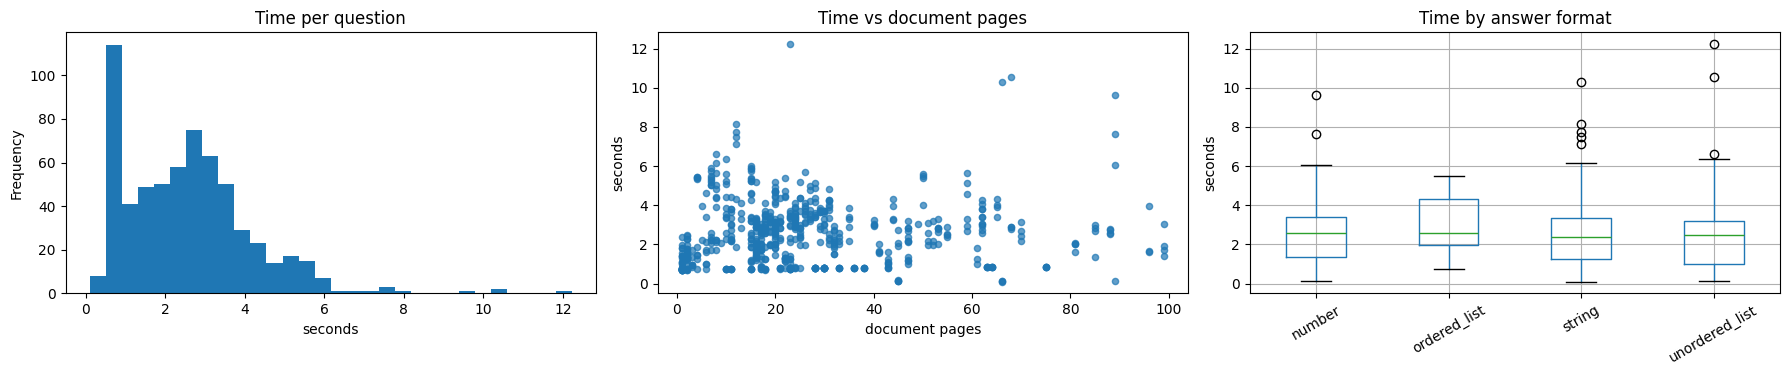

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

analysis_df["time_seconds"].plot.hist(bins=30, ax=axes[0], title="Time per question")
axes[0].set_xlabel("seconds")

analysis_df.plot.scatter(x="num_pages", y="time_seconds", ax=axes[1], title="Time vs document pages", alpha=0.7)
axes[1].set_xlabel("document pages")
axes[1].set_ylabel("seconds")

analysis_df.boxplot(column="time_seconds", by="answer_format", ax=axes[2], rot=30)
axes[2].set_title("Time by answer format")
axes[2].set_xlabel("")
axes[2].set_ylabel("seconds")

fig.suptitle("")
plt.tight_layout()
plt.show()

## Train Score Analysis

In [9]:
score_cols = ["vqa_score", "grounding_score", "overall_score"]
if all(col in analysis_df.columns for col in score_cols):
    print("Aggregate score by answer format")
    display(analysis_df.groupby("answer_format")[score_cols].mean().round(4))

    print("Worst questions by overall_score")
    cols = [
        "id", "answer_format", "language", "num_pages", "predicted_answer",
        "ground_truth_answer", "vqa_score", "grounding_score", "overall_score",
        "retriever_missed", "time_seconds",
    ]
    display(analysis_df[cols].sort_values("overall_score").head(50))
else:
    print("This run has no ground-truth score columns, which is expected for test split runs.")

This run has no ground-truth score columns, which is expected for test split runs.


## Compare Runs

In [10]:
runs_dir = Path("../runs")
rows = []
for run_path in sorted(runs_dir.iterdir()):
    summary_file = run_path / "summary.json"
    config_file = run_path / "config.json"
    if not summary_file.exists() or not config_file.exists():
        continue
    with open(summary_file, encoding="utf-8") as f:
        s = json.load(f)
    with open(config_file, encoding="utf-8") as f:
        c = json.load(f)
    rows.append({
        "run": run_path.name,
        "split": c.get("split"),
        "backend": c.get("backend", s.get("backend")),
        "dense_model": c.get("dense_model"),
        "min_pages": c.get("retriever_min_pages"),
        "max_pages": c.get("retriever_max_pages"),
        "num_questions": s.get("num_questions"),
        "parse_failures": s.get("parse_failures"),
        "mean_vqa": s.get("mean_vqa_score"),
        "mean_grounding": s.get("mean_grounding_score"),
        "mean_overall": s.get("mean_overall_score"),
        "avg_time": s.get("avg_time_per_question_sec"),
        "p95_time": s.get("p95_time_sec"),
        "total_time_sec": s.get("total_time_sec"),
    })

compare_df = pd.DataFrame(rows)
if compare_df.empty:
    print("No comparable run summaries found.")
else:
    display(compare_df.sort_values(["split", "run"]))

,run,split,backend,dense_model,min_pages,max_pages,num_questions,parse_failures,mean_vqa,mean_grounding,mean_overall,avg_time,p95_time,total_time_sec
7,23894,test,vllm,None,NaN,NaN,624,194.0,NaN,NaN,NaN,5.66,16.53,3533.43
8,23933,test,vllm,intfloat/multilingual-e5-large,3.0,7.0,624,155.0,NaN,NaN,NaN,2.57,5.38,1606.26
0,23515,train,None,None,NaN,NaN,16,NaN,0.1562,0.5365,0.3463,25.32,NaN,405.12
1,23533,train,None,None,NaN,NaN,16,NaN,0.4062,0.8807,0.6435,18.63,NaN,298.06
2,23582,train,None,None,NaN,NaN,16,NaN,0.4062,0.8807,0.6435,21.17,NaN,338.71
3,23583,train,None,None,NaN,NaN,16,NaN,0.4062,0.8807,0.6435,18.36,NaN,293.80
4,23588,train,None,None,NaN,NaN,16,NaN,0.4562,0.8823,0.6693,20.76,NaN,332.12
5,23609,train,None,None,NaN,NaN,16,NaN,0.4562,0.8990,0.6776,27.39,NaN,438.20
6,23616,train,None,None,NaN,NaN,16,NaN,0.3937,0.8744,0.6341,58.36,NaN,933.75
